In [1]:
import pandas as pd
import numpy as np
import time
import xgboost as xgb
import tensorflow

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from sklearn.feature_selection import f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import plot_importance
import warnings
import pickle
warnings.filterwarnings("ignore")

***Read the dataset with pandas***

In [2]:
df = pd.read_csv('NVD_Cybersecurity_Dataset.csv')
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()


Shape: (337705, 19)

Columns:
['CVE_ID', 'Published_Date', 'Publish_Year', 'Publish_Month', 'Description', 'Clean_Description', 'Word_Count', 'Char_Length', 'Flag_XSS', 'Flag_SQLi', 'Flag_Buffer_Overflow', 'Flag_RCE', 'Flag_Privilege_Escalation', 'Flag_DoS', 'Flag_Directory_Traversal', 'CVSS_Base_Score', 'Severity', 'Exploitability_Score', 'Impact_Score']


,CVE_ID,Published_Date,Publish_Year,Publish_Month,Description,Clean_Description,Word_Count,Char_Length,Flag_XSS,Flag_SQLi,Flag_Buffer_Overflow,Flag_RCE,Flag_Privilege_Escalation,Flag_DoS,Flag_Directory_Traversal,CVSS_Base_Score,Severity,Exploitability_Score,Impact_Score
0,CVE-1999-0095,1988-10-01,1988,10,"The debug command in Sendmail is enabled, allo...","the debug command in sendmail is enabled, allo...",14,89,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
1,CVE-1999-0082,1988-11-11,1988,11,CWD ~root command in ftpd allows root access.,cwd ~root command in ftpd allows root access.,8,45,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0
2,CVE-1999-1471,1989-01-01,1989,1,Buffer overflow in passwd in BSD based operati...,buffer overflow in passwd in bsd based operati...,27,158,0,0,1,0,0,0,0,7.2,HIGH,3.9,10.0
3,CVE-1999-1122,1989-07-26,1989,7,Vulnerability in restore in SunOS 4.0.3 and ea...,vulnerability in restore in sunos 4.0.3 and ea...,14,90,0,0,0,0,0,0,0,4.6,MEDIUM,3.9,6.4
4,CVE-1999-1467,1989-10-26,1989,10,Vulnerability in rcp on SunOS 4.0.x allows rem...,vulnerability in rcp on sunos 4.0.x allows rem...,27,175,0,0,0,0,0,0,0,10.0,HIGH,10.0,10.0


Basic cleaning

*   Strip extra spaces from column names
*   Check missing values
*   Identify the target column

In [3]:
# Clean column names
df.columns = df.columns.str.strip()

print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

target_col = "CVSS_Base_Score"
print("\nTarget column:", target_col)
print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

Missing values per column:
CVE_ID                       0
Published_Date               0
Publish_Year                 0
Publish_Month                0
Description                  0
Clean_Description            0
Word_Count                   0
Char_Length                  0
Flag_XSS                     0
Flag_SQLi                    0
Flag_Buffer_Overflow         0
Flag_RCE                     0
Flag_Privilege_Escalation    0
Flag_DoS                     0
Flag_Directory_Traversal     0
dtype: int64

Target column: CVSS_Base_Score

Target distribution:
CVSS_Base_Score
7.5    36747
7.8    23250
9.8    23127
0.0    22057
4.3    19948
       ...  
1.0        8
9.2        5
9.7        4
1.4        2
1.3        2
Name: count, Length: 90, dtype: int64


***Separate features and target***

In [4]:
# Separate features and target
target_col = "CVSS_Base_Score"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# High-cardinality text columns to drop
drop_cols = [col for col in ["CVE_ID", "Published_Date", "Description",	"Clean_Description", "Exploitability_Score",	"Impact_Score"] if col in X.columns]
X = X.drop(columns=drop_cols)

print("Dropped columns:", drop_cols)
print("Remaining feature shape:", X.shape)

Dropped columns: ['CVE_ID', 'Published_Date', 'Description', 'Clean_Description', 'Exploitability_Score', 'Impact_Score']
Remaining feature shape: (337705, 12)


***Detect numeric and categorical columns***

In [5]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumber of numeric columns:", len(numeric_cols))

Categorical columns: ['Severity']

Number of numeric columns: 11


In [6]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

**Train/test split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (270164, 18)
X_test: (67541, 18)


***Preprocessing and feature selection***

In [8]:
k_features = 40

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ***Gradient Boosting***

In [9]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        max_depth=5
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

# ***Predicted vs Actual***

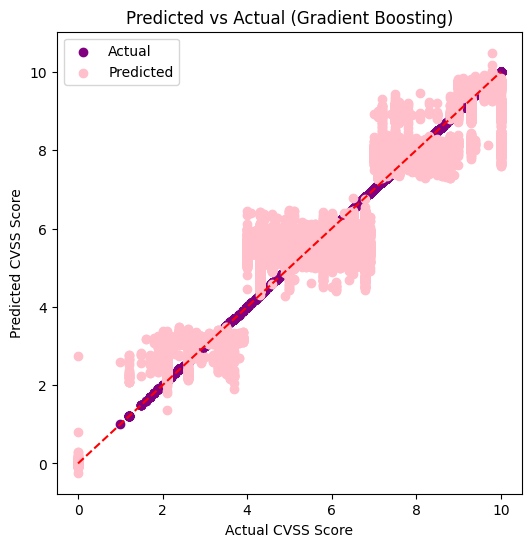

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, gb_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (Gradient Boosting)")
plt.legend()
plt.show()

In [11]:
# Evaluation
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results:")
print("MAE:", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²:", round(gb_r2, 4))

Gradient Boosting Results:
MAE: 0.4693
RMSE: 0.6292
R²: 0.9322


# **Prediction Time**

In [12]:
start = time.time()
gb_pred = gb_pipeline.predict(X_test)
gb_time = time.time() - start

print("Prediction Time:", round(gb_time, 4), "seconds")

Prediction Time: 0.5399 seconds


# ***XGBRefressor***

In [13]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

***Hyperparameter Tuning***

In [14]:
param_grid = {
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

**XGBRefressor pipeline**

In [15]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", xgb_model)
])

**Optimised model performance with gridsearch**

In [16]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__subsample': 0.8}


***Using the beset model***

In [17]:
best_model = grid_search.best_estimator_

xgb_pred = best_model.predict(X_test)

# ***Predicted vs Actual***

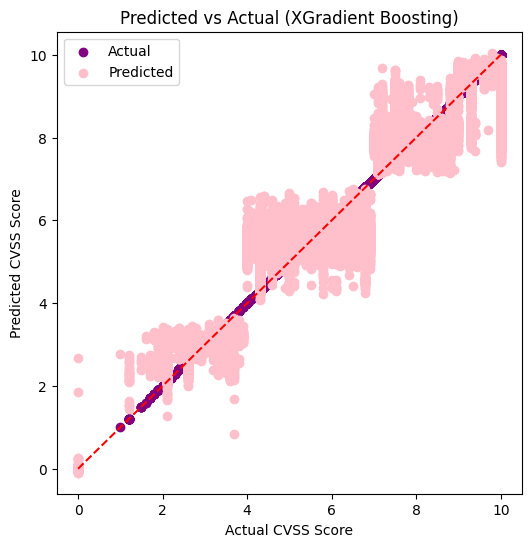

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, xgb_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (XGradient Boosting)")
plt.legend()
plt.show()

In [19]:
# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results:")
print("MAE:", round(xgb_mae, 4))
print("RMSE:", round(xgb_rmse, 4))
print("R²:", round(xgb_r2, 4))

XGBoost Results:
MAE: 0.4424
RMSE: 0.6113
R²: 0.936


# **Prediction Time**

In [21]:
start = time.time()
xgb_pred = gb_pipeline.predict(X_test)
xgb_time = time.time() - start

print("Prediction Time:", round(xgb_time, 4), "seconds")

Prediction Time: 0.4928 seconds


## ***AdaBoost***

In [20]:
ada_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=200, #improve's learning
        learning_rate=0.1,
        random_state=42
    ))
])

***Train and Predict***

In [22]:
ada_pipeline.fit(X_train, y_train)

ada_pred = ada_pipeline.predict(X_test)

# ***Predicted vs Actual***

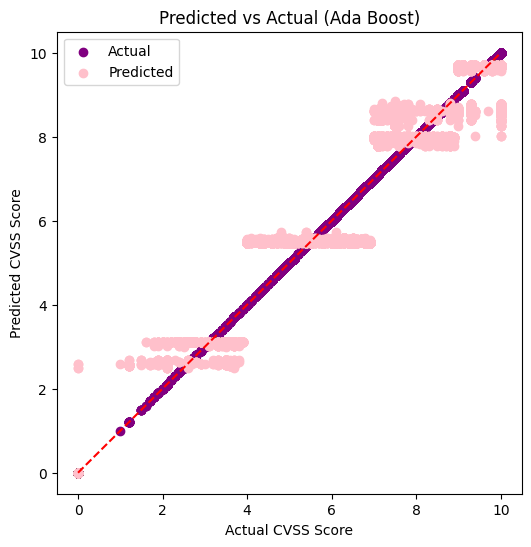

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, ada_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (Ada Boost)")
plt.legend()
plt.show()

In [24]:
# Evaluation
ada_mae = mean_absolute_error(y_test, ada_pred)
ada_rmse = np.sqrt(mean_squared_error(y_test, ada_pred))
ada_r2 = r2_score(y_test, ada_pred)

print("AdaBoost Results:")
print("MAE:", round(ada_mae, 4))
print("RMSE:", round(ada_rmse, 4))
print("R²:", round(ada_r2, 4))

AdaBoost Results:
MAE: 0.5557
RMSE: 0.6972
R²: 0.9168


# **Prediction Time**

In [25]:
start = time.time()
ada_pred = ada_pipeline.predict(X_test)
ada_time = time.time() - start

print("Prediction Time:", round(ada_time, 4), "seconds")

Prediction Time: 1.4836 seconds


# ***K Nearest Neighbour (regression version)***

In [26]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", KNeighborsRegressor(
        n_neighbors=5,
        weights='distance',
        metric='minkowski'
    ))
])

training

In [27]:
knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

# ***Predicted vs Actual***

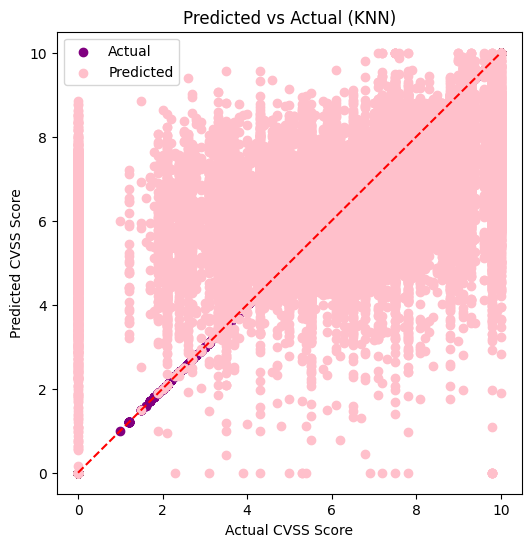

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, knn_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (KNN)")
plt.legend()
plt.show()

In [29]:
# Evaluation
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Results:")
print("MAE:", round(knn_mae, 4))
print("RMSE:", round(knn_rmse, 4))
print("R²:", round(knn_r2, 4))

KNN Results:
MAE: 0.9542
RMSE: 1.4846
R²: 0.6226


# **Prediction Time**

In [30]:
start = time.time()
knn_pred = knn_pipeline.predict(X_test)
knn_time = time.time() - start

print("Prediction Time:", round(knn_time, 4), "seconds")

Prediction Time: 122.8 seconds


# ***Random Forest Regressor***

In [31]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

# ***Predicted vs Actual***

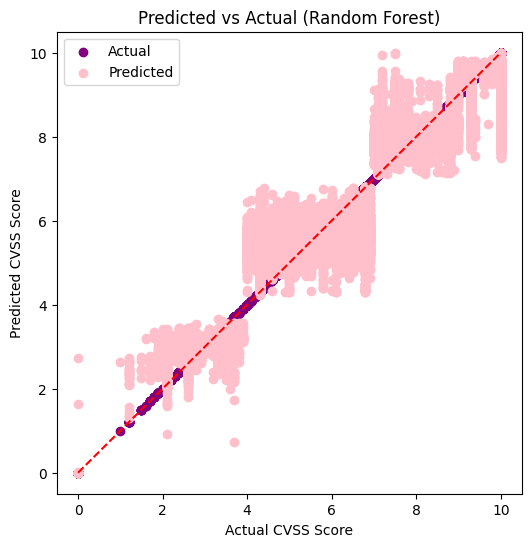

In [32]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, rf_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (Random Forest)")
plt.legend()
plt.show()

In [33]:
# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print("RF Results:")
print("MAE:", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²:", round(rf_r2, 4))

RF Results:
MAE: 0.4324
RMSE: 0.6089
R²: 0.9365


# ***Prediction***

In [34]:
start = time.time()
rf_pred = rf_pipeline.predict(X_test)
rf_time = time.time() - start

print("Prediction Time:", round(rf_time, 4), "seconds")

Prediction Time: 1.5271 seconds


# ***Decison Tree***

In [35]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_regression, k=k_features)),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
])

# ***Predicted vs Actual***

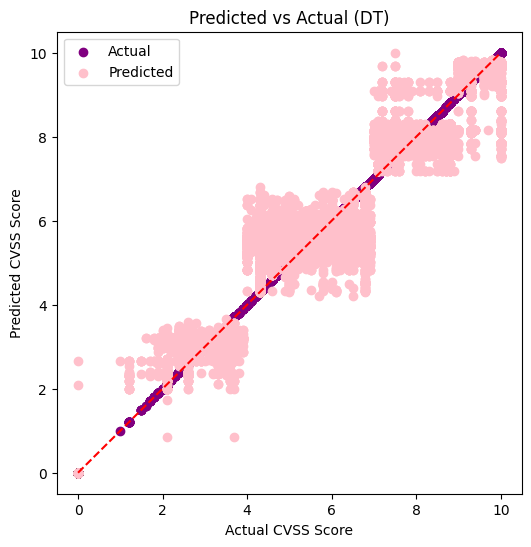

In [36]:
dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, dt_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (DT)")
plt.legend()
plt.show()

In [37]:
# Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("DT Results:")
print("MAE:", round(dt_mae, 4))
print("RMSE:", round(dt_rmse, 4))
print("R²:", round(dt_r2, 4))

DT Results:
MAE: 0.4566
RMSE: 0.6295
R²: 0.9321


# **Prediction Time**

In [38]:
start = time.time()
dt_pred = dt_pipeline.predict(X_test)
dt_time = time.time() - start

print("Prediction Time:", round(dt_time, 4), "seconds")

Prediction Time: 0.0674 seconds


# ***D Neural Networks***

In [67]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [68]:
dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

In [69]:
from tensorflow.keras.optimizers import RMSprop
optimizer = RMSprop(0.01)

In [70]:
dnn.compile(loss='mean_squared_error',optimizer=optimizer)

In [71]:
# fit the model
dnn.fit(
    X_train_processed,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 382.0841 - val_loss: 3.1634
Epoch 2/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 2.2147 - val_loss: 1.6513
Epoch 3/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.6264 - val_loss: 0.6522
Epoch 4/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.3632 - val_loss: 1.7461
Epoch 5/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.2222 - val_loss: 1.7708
Epoch 6/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.1437 - val_loss: 0.7644
Epoch 7/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.0906 - val_loss: 0.8950
Epoch 8/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.0558 - val_loss: 1.1157
Epoch 9/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1.0294 - val_loss: 1.2827
Epoch 10/10
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.0149 - val_loss: 1.2435


In [72]:
dnn_pred = dnn.predict(X_test_processed).flatten()

2111/2111 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


# ***Predicted vs Actual***

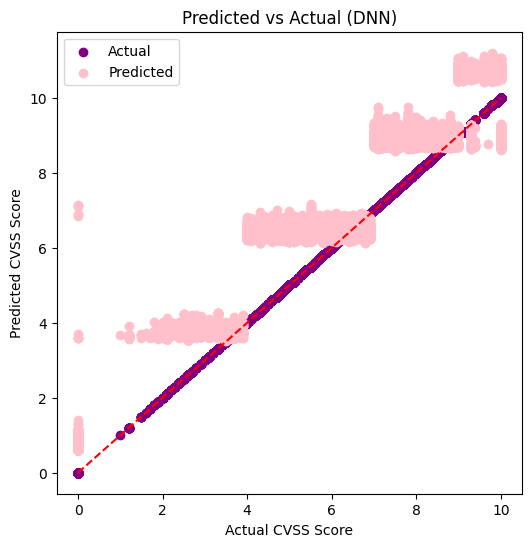

In [73]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, dnn_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (DNN)")
plt.legend()
plt.show()

In [74]:
# Evaluation
dnn_mae = mean_absolute_error(y_test, dnn_pred)
dnn_rmse = np.sqrt(mean_squared_error(y_test, dnn_pred))
dnn_r2 = r2_score(y_test, dnn_pred)

print("DNN Results:")
print("MAE:", round(dnn_mae, 4))
print("RMSE:", round(dnn_rmse, 4))
print("R²:", round(dnn_r2, 4))

DNN Results:
MAE: 0.9446
RMSE: 1.114
R²: 0.7875


# **Prediction Time**

In [75]:
start = time.time()
dnn_pred = dnn.predict(X_test_processed)
dnn_time = time.time() - start

print("Prediction Time:", round(dnn_time, 4), "seconds")

2111/2111 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Prediction Time: 3.1853 seconds


# ***CNN***

In [76]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [77]:
X_train_cnn = X_train_processed.reshape((X_train_processed.shape[0], X_train_processed.shape[1], 1))
X_test_cnn = X_test_processed.reshape((X_test_processed.shape[0], X_test_processed.shape[1], 1))

In [78]:
print(X_train_processed.shape)

(270164, 17)


In [79]:
cnn = Sequential([
    Conv1D(32, 2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

cnn.fit(X_train_cnn, y_train, epochs=10, batch_size=64)

cnn_pred = cnn.predict(X_test_cnn).flatten()

Epoch 1/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.6262 - mae: 1.0269
Epoch 2/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.6432 - mae: 0.8554
Epoch 3/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1.1002 - mae: 0.8034
Epoch 4/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.9095 - mae: 0.7368
Epoch 5/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.8227 - mae: 0.7091
Epoch 6/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.7233 - mae: 0.6696
Epoch 7/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.6612 - mae: 0.6427
Epoch 8/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.5957 - mae: 0.6128
Epoch 9/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.5559 - mae: 0.5899
Epoch 10/10
4222/4222 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.5331 - mae: 0.5776
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


# ***Predicted vs Actual***

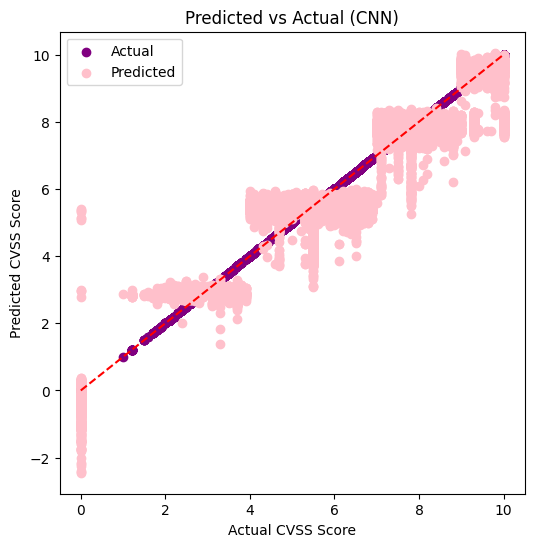

In [80]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, color='purple', label='Actual')
plt.scatter(y_test, cnn_pred, color='pink', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'red', linestyle='--')
plt.xlabel("Actual CVSS Score")
plt.ylabel("Predicted CVSS Score")
plt.title("Predicted vs Actual (CNN)")
plt.legend()
plt.show()

In [81]:
# Evaluation
cnn_mae = mean_absolute_error(y_test, cnn_pred)
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_pred))
cnn_r2 = r2_score(y_test, cnn_pred)

print("CNN Results:")
print("MAE:", round(cnn_mae, 4))
print("RMSE:", round(cnn_rmse, 4))
print("R²:", round(cnn_r2, 4))

CNN Results:
MAE: 0.5581
RMSE: 0.7242
R²: 0.9102


# **Prediction Time**

In [82]:
start = time.time()

cnn_pred = cnn.predict(X_test_cnn).flatten()

cnn_time = time.time() - start

print("CNN Prediction Time:", round(cnn_time, 4), "seconds")

2111/2111 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
CNN Prediction Time: 4.3866 seconds


# ***Compparison of models***

In [83]:
results = [
    ["Gradient Boosting", gb_mae, gb_rmse, gb_r2, gb_time],
    ["XGBoost", xgb_mae, xgb_rmse, xgb_r2, xgb_time],
    ["AdaBoost", ada_mae, ada_rmse, ada_r2, ada_time],
    ["KNN", knn_mae, knn_rmse, knn_r2, knn_time],
    ["Random Forest", rf_mae, rf_rmse, rf_r2, rf_time],
    ["Decision Tree", dt_mae, dt_rmse, dt_r2, dt_time],
    ["DNN", dnn_mae, dnn_rmse, dnn_r2, dnn_time],
    ["CNN", cnn_mae, cnn_rmse, cnn_r2, cnn_time]
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R²", "Prediction Time (s)"]
)

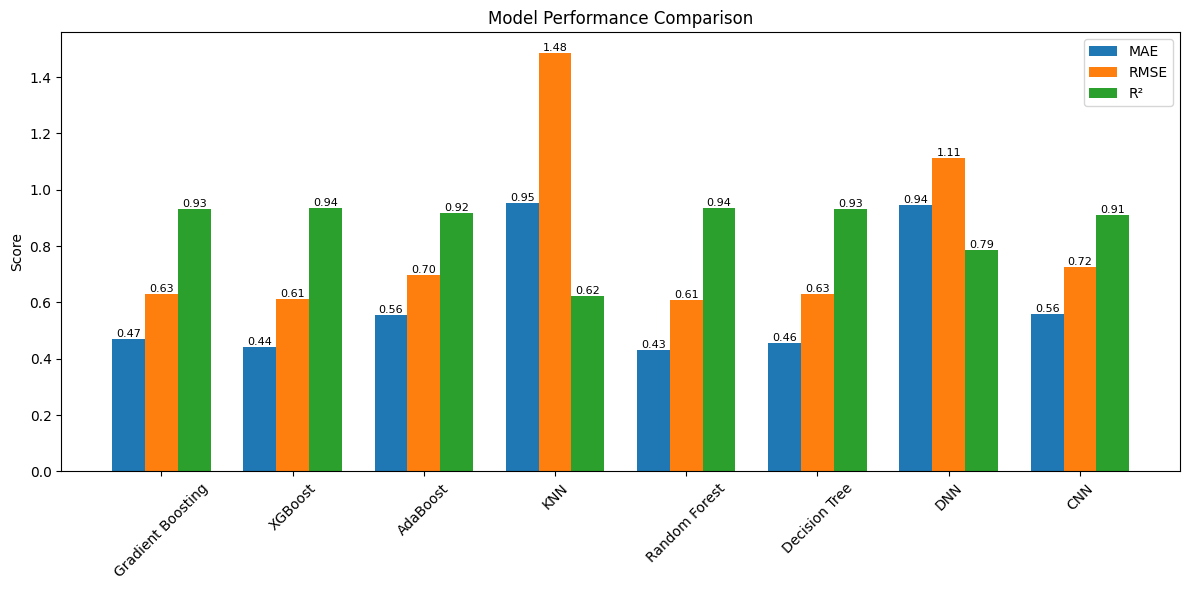

In [84]:
metrics = ["MAE", "RMSE", "R²"]
models = results_df["Model"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    values = results_df[metric]
    bars = plt.bar(x + i*width, values, width, label=metric)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x + width, models, rotation=45)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# **Prediction Time**

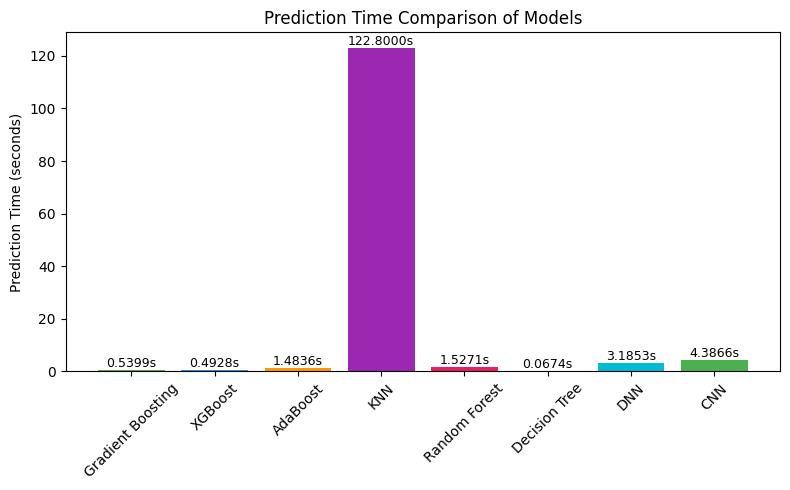

In [85]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Prediction Time (s)"],
    color=["#4CAF50","#2196F3","#FF9800","#9C27B0","#E91E63","#795548","#00BCD4"]
)

# add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=45)
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison of Models")

plt.tight_layout()
plt.show()

# ***Correlation Heatmap***

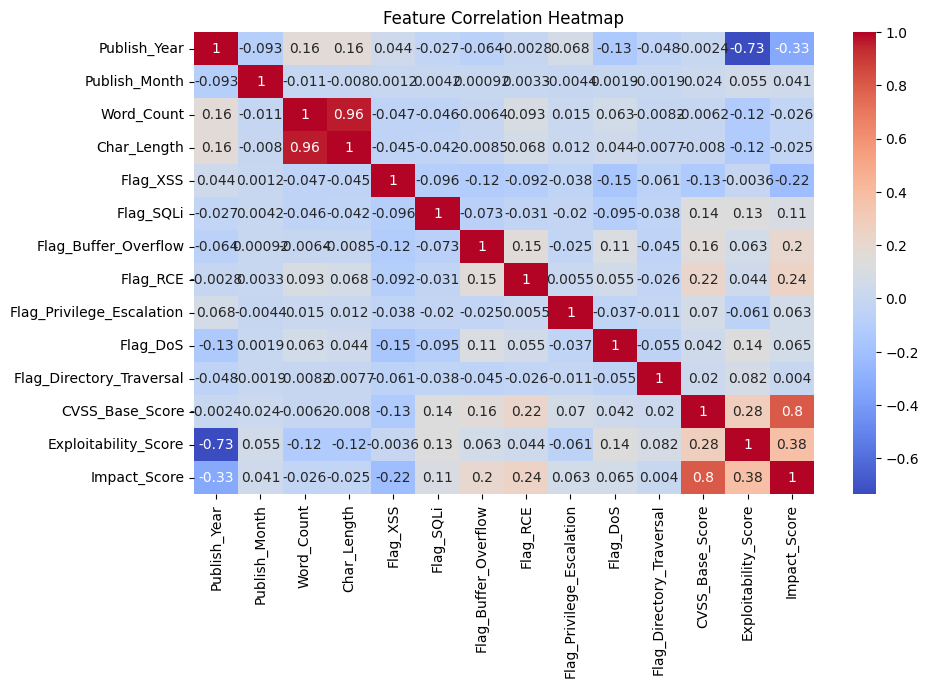

In [86]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ***Saving the models***

In [87]:
pickle.dump(gb_pipeline, open("gradient_boosting.pkl", "wb"))
pickle.dump(xgb_pipeline, open("xgboost.pkl", "wb"))
pickle.dump(ada_pipeline, open("adaBoost.pkl", "wb"))
pickle.dump(knn_pipeline, open("knn.pkl", "wb"))
pickle.dump(rf_pipeline, open("rf.pkl", "wb"))
pickle.dump(dt_pipeline, open("dt.pkl", "wb"))

dnn.save("dnn.h5")
cnn.save("cnn.h5")